# Label Proxy Dashboard (STEP 5.6)

Configurable supervision targets for `data_training_full_rebuilt/`. Build a proxy, inspect its
diagnostics/plots, and compare the four proxies side-by-side. **These are proxy labels, not ground truth.**

In [1]:
# === CONFIG ===
DATA_DIR = 'data_training_full_rebuilt'
PROXY    = 'hybrid_rt_nasa'   # nasa_tlx | dual_task_rt | nasa_time_weighted | hybrid_rt_nasa
CONFIG   = {
    # nasa / time-weighted:
    'state_mode': '5class',          # none | 3class | 5class (nasa) ; none|binary|3class (dual/hybrid)
    'weight_function': 'sigmoid',    # linear | quadratic | sigmoid | exponential
    'min_weight': 0.2, 'max_weight': 1.0, 'sigmoid_k': 8.0,
    # dual_task / hybrid:
    'rt_weight': 0.8, 'miss_weight': 0.2, 'error_weight': 0.0,
    'alpha_rt': 0.7,
}
import sys, json
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT))
from scripts.labels.label_proxy import build_label_proxy

In [2]:
res = build_label_proxy(ROOT/DATA_DIR, PROXY, CONFIG)
m = res['mask']
print('proxy:', res['proxy_name'], '| target_names:', res['target_names'])
print('usable:', int(m.sum()), '/', len(res['metadata']))
print(json.dumps(res['diagnostics'].get('coverage', res['diagnostics']), indent=2, default=str)[:500])

proxy: hybrid_rt_nasa | target_names: ['hybrid_load']
usable: 806 / 806
{
  "available": 211,
  "missing": 595,
  "coverage_pct": 26.18,
  "by_user": {
    "Graja": {
      "available": 0,
      "total": 11
    },
    "Makki": {
      "available": 5,
      "total": 15
    },
    "amrdroid": {
      "available": 5,
      "total": 16
    },
    "browser_mp835qq4j4kymt": {
      "available": 65,
      "total": 231
    },
    "browser_mp8quvqu5u5czy": {
      "available": 0,
      "total": 16
    },
    "dem": {
      "available": 105,
      "total": 345
    },
    "dev


## Target & weight distributions for the chosen proxy

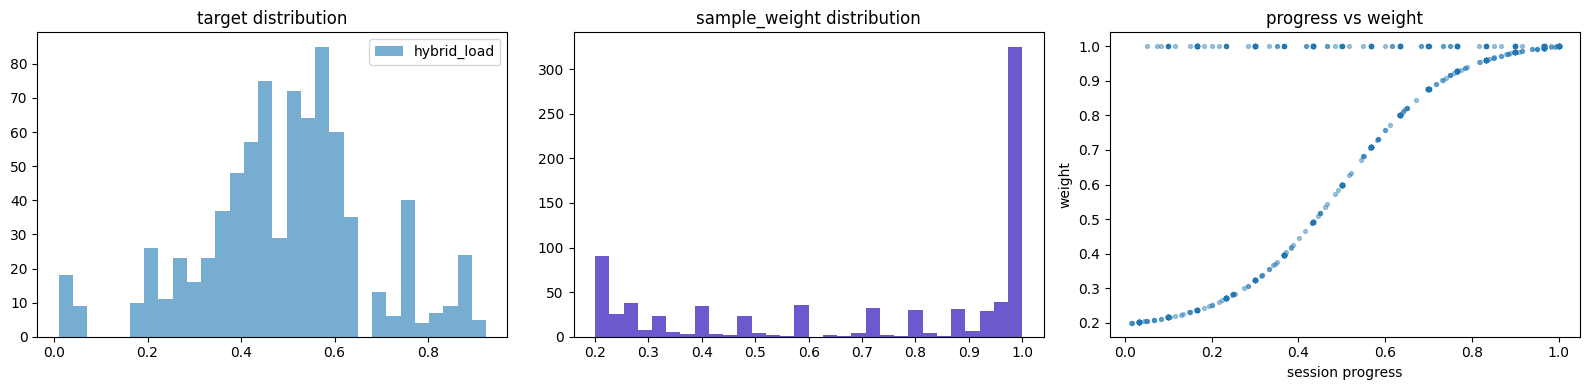

In [3]:
t = res['targets']; w = res['sample_weights']; prog = res['progress']
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for j, nm in enumerate(res['target_names']):
    ax[0].hist(t[m, j], bins=30, alpha=0.6, label=nm)
ax[0].set_title('target distribution'); ax[0].legend()
ax[1].hist(w[m], bins=30, color='slateblue'); ax[1].set_title('sample_weight distribution')
ax[2].scatter(prog[m], w[m], s=8, alpha=0.4); ax[2].set_xlabel('session progress'); ax[2].set_ylabel('weight')
ax[2].set_title('progress vs weight')
plt.tight_layout(); plt.show()

## Compare all four proxies side-by-side

In [4]:
import pandas as pd
rows = []
for p in ['nasa_tlx', 'dual_task_rt', 'nasa_time_weighted', 'hybrid_rt_nasa']:
    r = build_label_proxy(ROOT/DATA_DIR, p, CONFIG if p in (PROXY,) else None)
    mm = r['mask']; d = r['diagnostics']
    rows.append({'proxy': p, 'target_dim': r['targets'].shape[1], 'usable': int(mm.sum()),
                 'coverage_pct': d.get('coverage', {}).get('coverage_pct'),
                 'target_mean': d.get('target_mean'),
                 'rt_vs_nasa_corr': d.get('rt_vs_nasa_load_corr'),
                 'has_states': r['state_labels'] is not None})
pd.DataFrame(rows)

,proxy,target_dim,usable,coverage_pct,target_mean,rt_vs_nasa_corr,has_states
0,nasa_tlx,5,806,100.00,"[0.5244, 0.5184, 0.4643, 0.4038, 0.4342]",NaN,True
1,dual_task_rt,1,211,26.18,[0.5777],NaN,False
2,nasa_time_weighted,5,806,100.00,"[0.5244, 0.5184, 0.4643, 0.4038, 0.4342]",NaN,True
3,hybrid_rt_nasa,1,806,26.18,[0.4934],-0.135425,False


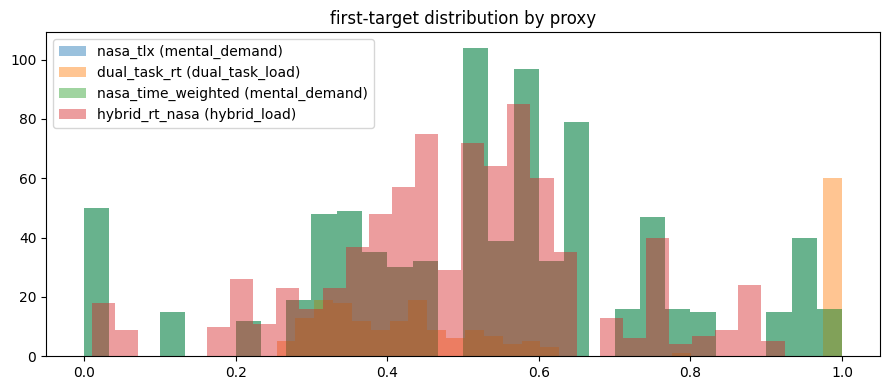

In [5]:
# target distributions overlaid (first target dim of each proxy)
plt.figure(figsize=(9, 4))
for p in ['nasa_tlx', 'dual_task_rt', 'nasa_time_weighted', 'hybrid_rt_nasa']:
    r = build_label_proxy(ROOT/DATA_DIR, p)
    mm = r['mask']
    plt.hist(r['targets'][mm, 0], bins=30, alpha=0.45, label=f"{p} ({r['target_names'][0]})")
plt.legend(); plt.title('first-target distribution by proxy'); plt.tight_layout(); plt.show()

## Notes
- `nasa_tlx`: 100% coverage but **session-level** (constant within a session).
- `dual_task_rt`: **window-level** but **sparse** (~26% of windows).
- `nasa_time_weighted`: NASA targets, sample-weighted toward end-of-session (a **hypothesis**).
- `hybrid_rt_nasa`: RT where available else time-weighted NASA — a **modeling assumption**, not ground truth.
  Note the RT-load vs NASA-load correlation in diagnostics is weak/slightly negative.

STEP 6 trainers consume these via `scripts/predictive/label_proxy_integration.load_targets_for_training`.